In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

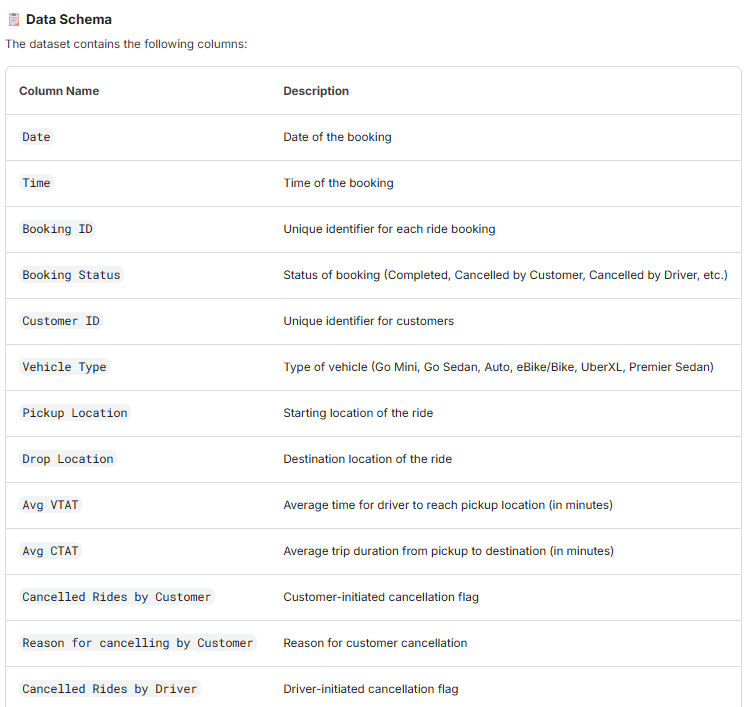

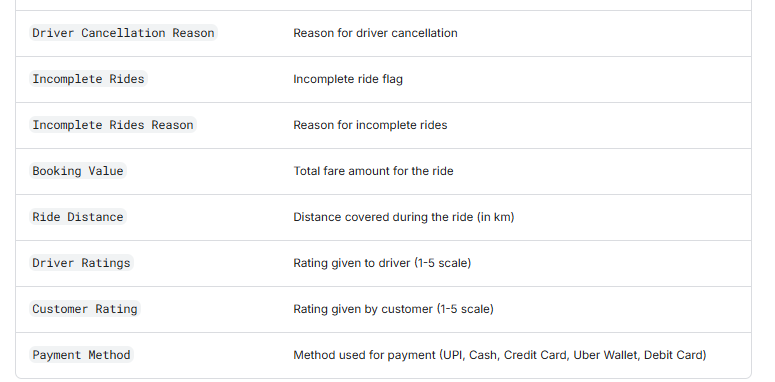

Reading the dataset

In [6]:
df = pd.read_excel(r"C:\Users\tsrap\Downloads\ncr_ride_bookings.csv.xlsx")

In [7]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


Summary of the Dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [10]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  datetime64[ns]
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [12]:
df['Incomplete Rides'].unique()

array([nan,  1.])

In [13]:
df['Cancelled Rides by Driver'].unique()

array([nan,  1.])

In [14]:
df['Cancelled Rides by Customer'].unique()

array([nan,  1.])

Missing Values

In [16]:
df.isnull().sum().sort_values(ascending=False)

Incomplete Rides Reason              141000
Incomplete Rides                     141000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Driver Cancellation Reason           123000
Cancelled Rides by Driver            123000
Customer Rating                       57000
Driver Ratings                        57000
Ride Distance                         48000
Booking Value                         48000
Payment Method                        48000
Avg CTAT                              48000
Avg VTAT                              10500
Time                                      0
Drop Location                             0
Pickup Location                           0
Vehicle Type                              0
Customer ID                               0
Booking Status                            0
Booking ID                                0
Date                                      0
dtype: int64

In [17]:
((df.isnull().sum() / len(df)) * 100).round(2).sort_values(ascending=False)

Incomplete Rides Reason              94.0
Incomplete Rides                     94.0
Cancelled Rides by Customer          93.0
Reason for cancelling by Customer    93.0
Driver Cancellation Reason           82.0
Cancelled Rides by Driver            82.0
Customer Rating                      38.0
Driver Ratings                       38.0
Ride Distance                        32.0
Booking Value                        32.0
Payment Method                       32.0
Avg CTAT                             32.0
Avg VTAT                              7.0
Time                                  0.0
Drop Location                         0.0
Pickup Location                       0.0
Vehicle Type                          0.0
Customer ID                           0.0
Booking Status                        0.0
Booking ID                            0.0
Date                                  0.0
dtype: float64

C:\Users\tsrap\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


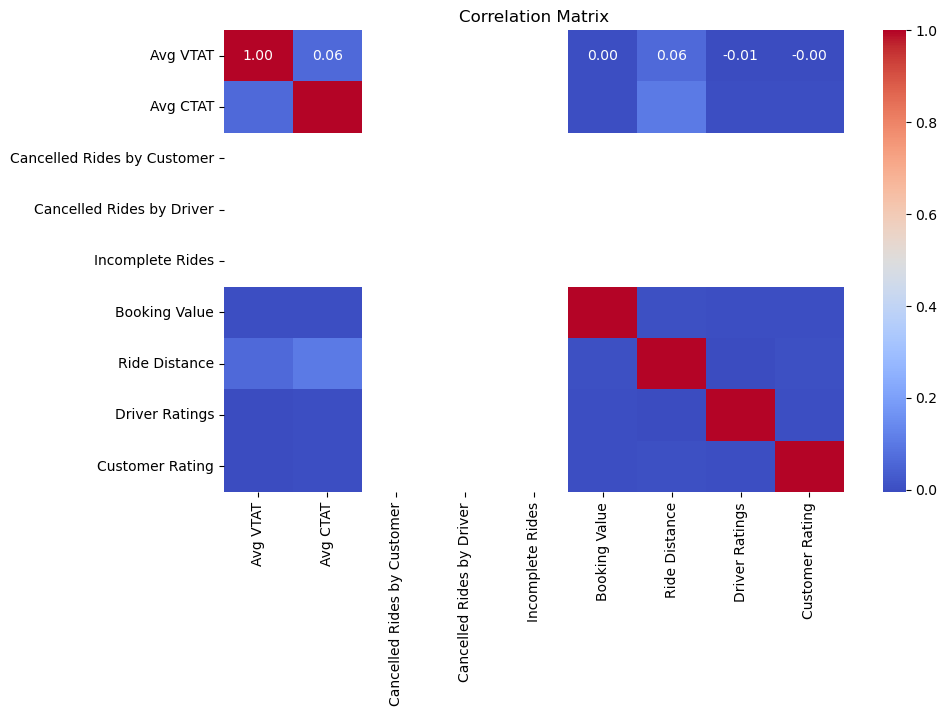

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Define Target Variable

In [20]:
df['Booking Status'].unique()

array(['No Driver Found', 'Incomplete', 'Completed',
       'Cancelled by Driver', 'Cancelled by Customer'], dtype=object)

In [21]:
df['is_cancelled'] = df['Booking Status'].isin([
    'Cancelled by Driver',
    'Cancelled by Customer',
    'No Driver Found',
    'Incomplete'
]).astype(int)

In [22]:
df.head(20)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,is_cancelled
0,2024-03-23,1900-01-01 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,2024-11-29,1900-01-01 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,1
2,2024-08-23,1900-01-01 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card,0
3,2024-10-21,1900-01-01 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI,0
4,2024-09-16,1900-01-01 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI,0
5,2024-02-06,1900-01-01 09:44:56,"""CNR4096693""",Completed,"""CID4670564""",Auto,AIIMS,Narsinghpur,5.1,18.1,...,NaN,NaN,NaN,NaN,316.0,4.85,4.1,4.6,UPI,0
6,2024-06-17,1900-01-01 15:45:58,"""CNR2002539""",Completed,"""CID6800553""",Go Mini,Vaishali,Punjabi Bagh,7.1,20.4,...,NaN,NaN,NaN,NaN,640.0,41.24,4.0,4.1,UPI,0
7,2024-03-19,1900-01-01 17:37:37,"""CNR6568000""",Completed,"""CID8610436""",Auto,Mayur Vihar,Cyber Hub,12.1,16.5,...,NaN,NaN,NaN,NaN,136.0,6.56,4.4,4.2,UPI,0
8,2024-09-14,1900-01-01 12:49:09,"""CNR4510807""",No Driver Found,"""CID7873618""",Go Sedan,Noida Sector 62,Noida Sector 18,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
9,2024-12-16,1900-01-01 19:06:48,"""CNR7721892""",Incomplete,"""CID5214275""",Auto,Rohini,Adarsh Nagar,6.1,26.0,...,NaN,NaN,1.0,Other Issue,135.0,10.36,NaN,NaN,Cash,1


In [23]:
df['Reason for cancelling by Customer'].unique()

array([nan, 'Driver is not moving towards pickup location',
       'Driver asked to cancel', 'AC is not working', 'Change of plans',
       'Wrong Address'], dtype=object)

## Exploratory Data Analysis (EDA)

### Understanding the target (is_cancelled)

In [26]:
df['is_cancelled'] = df['Booking Status'].isin([
    'Cancelled by Driver',
    'Cancelled by Customer',
    'No Driver Found',
    'Incomplete'
]).astype(int)

df['is_cancelled'].value_counts(normalize=True)

is_cancelled
0    0.62
1    0.38
Name: proportion, dtype: float64

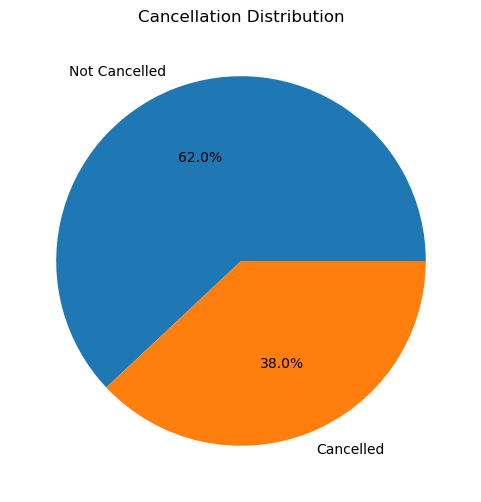

In [27]:
import matplotlib.pyplot as plt

# Get proportions
counts = df['is_cancelled'].value_counts()

# Labels
labels = ['Not Cancelled', 'Cancelled']

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%')

plt.title("Cancellation Distribution")
plt.show()

### Analyze cancellation reasons and location with respect to target 

In [29]:
df['Reason for cancelling by Customer'].value_counts()
df['Driver Cancellation Reason'].value_counts()

Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64

In [30]:
df.groupby('Pickup Location')['is_cancelled'].mean().mul(100).sort_values(ascending=False).head(10).round(2)

Pickup Location
Vinobapuri              45.32
Akshardham              43.86
Chhatarpur              41.86
Badshahpur              41.71
Pragati Maidan          41.52
Netaji Subhash Place    41.33
Vatika Chowk            41.30
Faridabad Sector 15     41.28
Indirapuram             41.10
IFFCO Chowk             40.84
Name: is_cancelled, dtype: float64

In [31]:
df[df['is_cancelled'] == 1] \
  .groupby('Pickup Location') \
  .size() \
  .sort_values(ascending=False) \
  .head(10)

Pickup Location
Pragati Maidan    382
Saket             374
Vinobapuri        373
Akshardham        368
Badshahpur        362
Udyog Vihar       358
AIIMS             356
Badarpur          354
GTB Nagar         352
Keshav Puram      352
dtype: int64

In [32]:
total_rides = df.groupby('Pickup Location').size()
counts = df.groupby('Pickup Location')['is_cancelled'].sum()
rates = df.groupby('Pickup Location')['is_cancelled'].mean() * 100

result = pd.DataFrame({
    'Total Rides': total_rides,
    'Count': counts,
    'Rate (%)': rates
}).sort_values(by='Rate (%)', ascending=False)

print(result.head(10))

                      Total Rides  Count   Rate (%)
Pickup Location                                    
Vinobapuri                    823    373  45.321993
Akshardham                    839    368  43.861740
Chhatarpur                    829    347  41.857660
Badshahpur                    868    362  41.705069
Pragati Maidan                920    382  41.521739
Netaji Subhash Place          830    343  41.325301
Vatika Chowk                  833    344  41.296519
Faridabad Sector 15           831    343  41.275572
Indirapuram                   854    351  41.100703
IFFCO Chowk                   830    339  40.843373


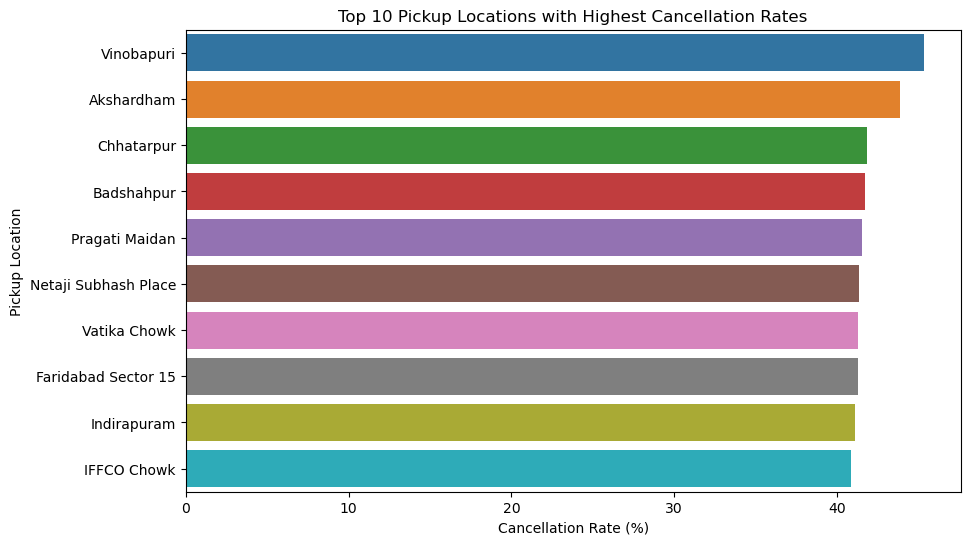

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

top_locations = (df.groupby('Pickup Location')['is_cancelled']
                 .mean()
                 .mul(100)
                 .sort_values(ascending=False)
                 .head(10)
                 .round(2)
                 .reset_index())

plt.figure(figsize=(10,6))
sns.barplot(data=top_locations, x='is_cancelled', y='Pickup Location')

plt.xlabel("Cancellation Rate (%)")
plt.ylabel("Pickup Location")
plt.title("Top 10 Pickup Locations with Highest Cancellation Rates")

plt.show()

### Vehicle type impact with repect to the target variable 

In [35]:
df['Vehicle Type'].value_counts().sort_values(ascending=False)

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

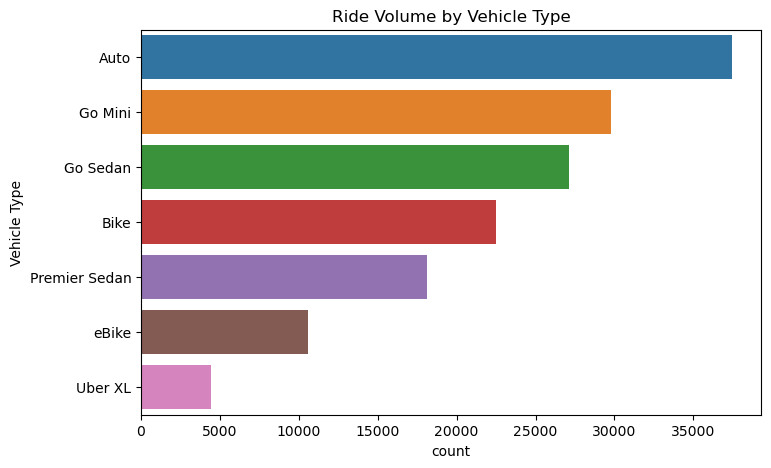

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='Vehicle Type', order=df['Vehicle Type'].value_counts().index)

plt.title("Ride Volume by Vehicle Type")
plt.show()

In [37]:
df.groupby('Vehicle Type')['is_cancelled'].mean().mul(100).round(2)

Vehicle Type
Auto             38.12
Bike             37.67
Go Mini          37.77
Go Sedan         38.56
Premier Sedan    37.87
Uber XL          37.45
eBike            37.95
Name: is_cancelled, dtype: float64

In [38]:
vehicle_table = df.groupby('Vehicle Type').agg(
    Total_Rides=('Vehicle Type', 'count'),
    Cancellation_Rate=('is_cancelled', lambda x: x.mean()*100)
).sort_values(by='Cancellation_Rate', ascending=False)

vehicle_table['Cancellation_Rate'] = vehicle_table['Cancellation_Rate'].round(2)

print(vehicle_table)

               Total_Rides  Cancellation_Rate
Vehicle Type                                 
Go Sedan             27141              38.56
Auto                 37419              38.12
eBike                10557              37.95
Premier Sedan        18111              37.87
Go Mini              29806              37.77
Bike                 22517              37.67
Uber XL               4449              37.45


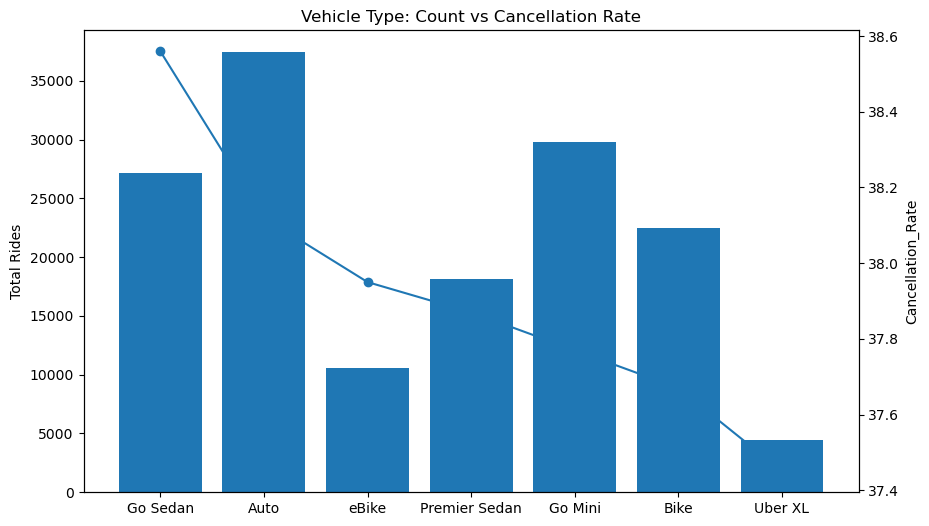

In [39]:
vehicle_table = vehicle_table.reset_index()

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar for counts
ax1.bar(vehicle_table['Vehicle Type'], vehicle_table['Total_Rides'])
ax1.set_ylabel("Total Rides")

# Line for rate
ax2 = ax1.twinx()
ax2.plot(vehicle_table['Vehicle Type'], vehicle_table['Cancellation_Rate'], marker='o')
ax2.set_ylabel("Cancellation_Rate")

plt.title("Vehicle Type: Count vs Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

In [40]:
print(vehicle_table.columns)

Index(['Vehicle Type', 'Total_Rides', 'Cancellation_Rate'], dtype='object')


### Time-based patterns

In [42]:
df['Date']=pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'])
df['hour'] = df['Time'].dt.hour

df.groupby('hour')['is_cancelled'].mean()

hour
0     0.375091
1     0.391176
2     0.362957
3     0.378163
4     0.371688
5     0.384422
6     0.372837
7     0.386055
8     0.378079
9     0.382560
10    0.375274
11    0.373778
12    0.380816
13    0.382815
14    0.387000
15    0.383443
16    0.380255
17    0.378848
18    0.385577
19    0.384629
20    0.376428
21    0.369493
22    0.384121
23    0.376539
Name: is_cancelled, dtype: float64

In [43]:
def get_time_period(hour):
    if 5 <= hour < 9:
        return 'Early Morning'
    elif 9 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_period'] = df['hour'].apply(get_time_period)

In [44]:
df.groupby('time_period')['is_cancelled'].mean().mul(100)

time_period
Afternoon        38.270580
Early Morning    38.012151
Evening          38.165828
Morning          37.708484
Night            37.566069
Name: is_cancelled, dtype: float64

In [45]:
df['day_of_week'] = df['Date'].dt.dayofweek

df.groupby('day_of_week')['is_cancelled'].mean()

day_of_week
0    0.384679
1    0.384274
2    0.379069
3    0.377516
4    0.380614
5    0.376010
6    0.377792
Name: is_cancelled, dtype: float64

In [46]:
df['day_name'] = df['Date'].dt.day_name()

In [47]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

result = (df.groupby('day_name')['is_cancelled']
          .mean()
          .mul(100)
          .reindex(order))

print(result)

day_name
Monday       38.467936
Tuesday      38.427376
Wednesday    37.906879
Thursday     37.751591
Friday       38.061410
Saturday     37.600966
Sunday       37.779232
Name: is_cancelled, dtype: float64


### Numeric feature comparison

In [49]:
df.groupby('is_cancelled')[[
    'Booking Value',
    'Ride Distance',
    'Avg CTAT',
    'Avg VTAT',
    'Driver Ratings',
    'Customer Rating'
]].mean()

,Booking Value,Ride Distance,Avg CTAT,Avg VTAT,Driver Ratings,Customer Rating
is_cancelled,,,,,,
0,508.178215,26.000493,30.034772,8.511878,4.230992,4.404584
1,509.512111,10.547706,20.003233,8.345299,NaN,NaN


In [50]:
df['customer_cancelled'] = df['Cancelled Rides by Customer'].notnull().astype(int)
df['driver_cancelled'] = df['Cancelled Rides by Driver'].notnull().astype(int)

In [51]:
cols = ['Avg CTAT', 'Avg VTAT', 'customer_cancelled', 'driver_cancelled']

corr = df[cols].corr()
print(corr)

                    Avg CTAT  Avg VTAT  customer_cancelled  driver_cancelled
Avg CTAT            1.000000  0.062175                 NaN               NaN
Avg VTAT            0.062175  1.000000            0.306655         -0.123904
customer_cancelled       NaN  0.306655            1.000000         -0.128540
driver_cancelled         NaN -0.123904           -0.128540          1.000000


In [52]:
df.groupby('driver_cancelled')[['Avg CTAT','Avg VTAT']].mean()
df.groupby('customer_cancelled')[['Avg CTAT','Avg VTAT']].mean()

,Avg CTAT,Avg VTAT
customer_cancelled,,
0,29.149636,8.126210
1,NaN,12.512381


### Payment method impact

In [54]:
df['Payment Method'].value_counts().sort_values(ascending=False)

Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

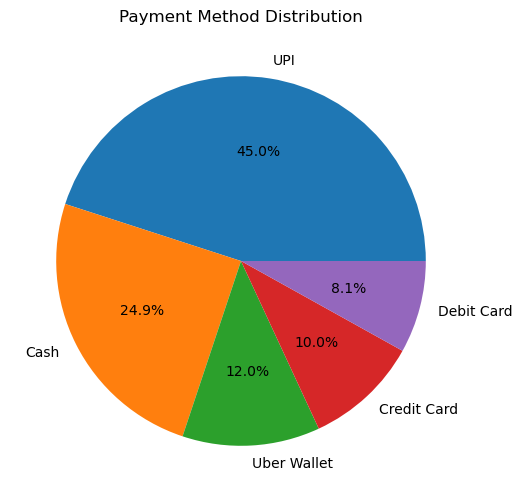

In [55]:
import matplotlib.pyplot as plt

counts = df['Payment Method'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

plt.title("Payment Method Distribution")
plt.show()

In [56]:
df.groupby('Payment Method')['is_cancelled'].mean()

Payment Method
Cash           0.088816
Credit Card    0.087080
Debit Card     0.086540
UPI            0.088763
Uber Wallet    0.087162
Name: is_cancelled, dtype: float64

In [57]:
df.isnull().mean().sort_values(ascending=False)

Incomplete Rides                     0.94
Incomplete Rides Reason              0.94
Reason for cancelling by Customer    0.93
Cancelled Rides by Customer          0.93
Driver Cancellation Reason           0.82
Cancelled Rides by Driver            0.82
Customer Rating                      0.38
Driver Ratings                       0.38
Payment Method                       0.32
Booking Value                        0.32
Ride Distance                        0.32
Avg CTAT                             0.32
Avg VTAT                             0.07
is_cancelled                         0.00
hour                                 0.00
time_period                          0.00
day_of_week                          0.00
day_name                             0.00
customer_cancelled                   0.00
Date                                 0.00
Time                                 0.00
Drop Location                        0.00
Pickup Location                      0.00
Vehicle Type                      

## Data Preprocessing

In [59]:
# Goal: Predict cancellation before it happens.
# But these columns ('Cancelled Rides by Customer','Reason for cancelling by Customer','Cancelled Rides by Driver',
#'Driver Cancellation Reason','Incomplete Rides','Incomplete Rides Reason) tells you that cancellation already happened -> Data Leakage

df_model = df.drop(columns=[
    'Booking ID','Customer ID','Booking Status',
    'Cancelled Rides by Customer','Reason for cancelling by Customer',
    'Cancelled Rides by Driver','Driver Cancellation Reason',
    'Incomplete Rides','Incomplete Rides Reason'
])

In [60]:
df_model.isnull().mean().sort_values(ascending=False)

Driver Ratings        0.38
Customer Rating       0.38
Avg CTAT              0.32
Booking Value         0.32
Ride Distance         0.32
Payment Method        0.32
Avg VTAT              0.07
hour                  0.00
customer_cancelled    0.00
day_name              0.00
day_of_week           0.00
time_period           0.00
Date                  0.00
is_cancelled          0.00
Time                  0.00
Drop Location         0.00
Pickup Location       0.00
Vehicle Type          0.00
driver_cancelled      0.00
dtype: float64

### Handling missing values

In [62]:
# Numeric
for col in ['Booking Value','Ride Distance','Avg CTAT','Avg VTAT']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Categorical
df_model['Payment Method'] = df_model['Payment Method'].fillna(df_model['Payment Method'].mode()[0])

In [63]:
# Ratings are given AFTER the ride is completed. So:
# If ride is completed → ratings exist
# If ride is cancelled → ratings = NaN

# We have to remove Ratings too or else we will face data leakage issue
df_model = df_model.drop(columns=['Driver Ratings','Customer Rating'])

In [64]:
df_model.isnull().mean().sort_values(ascending=False)

Date                  0.0
Payment Method        0.0
customer_cancelled    0.0
day_name              0.0
day_of_week           0.0
time_period           0.0
hour                  0.0
is_cancelled          0.0
Ride Distance         0.0
Time                  0.0
Booking Value         0.0
Avg CTAT              0.0
Avg VTAT              0.0
Drop Location         0.0
Pickup Location       0.0
Vehicle Type          0.0
driver_cancelled      0.0
dtype: float64

In [65]:
df_model = df_model.drop(columns=['customer_cancelled','driver_cancelled'])

In [66]:
df_model.shape

(150000, 15)

In [67]:
df_model.isnull().mean().sort_values(ascending=False)

Date               0.0
Time               0.0
Vehicle Type       0.0
Pickup Location    0.0
Drop Location      0.0
Avg VTAT           0.0
Avg CTAT           0.0
Booking Value      0.0
Ride Distance      0.0
Payment Method     0.0
is_cancelled       0.0
hour               0.0
time_period        0.0
day_of_week        0.0
day_name           0.0
dtype: float64

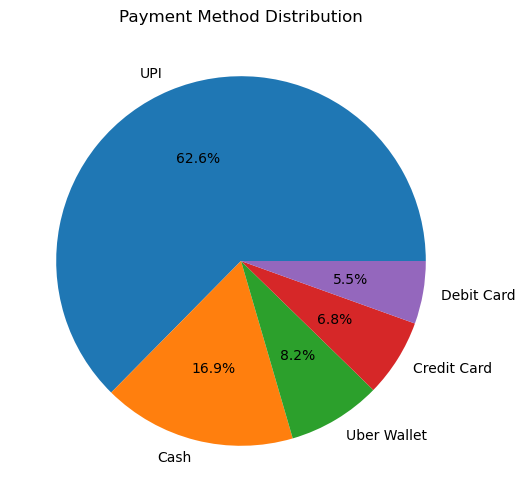

In [121]:
import matplotlib.pyplot as plt

counts = df_model['Payment Method'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

plt.title("Payment Method Distribution")
plt.show()

In [123]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

result = (df_model.groupby('day_name')['is_cancelled']
          .mean()
          .mul(100)
          .reindex(order))

print(result)

day_name
Monday       38.467936
Tuesday      38.427376
Wednesday    37.906879
Thursday     37.751591
Friday       38.061410
Saturday     37.600966
Sunday       37.779232
Name: is_cancelled, dtype: float64


In [127]:
df_model.groupby('time_period')['is_cancelled'].mean().mul(100)

time_period
Afternoon        38.270580
Early Morning    38.012151
Evening          38.165828
Morning          37.708484
Night            37.566069
Name: is_cancelled, dtype: float64

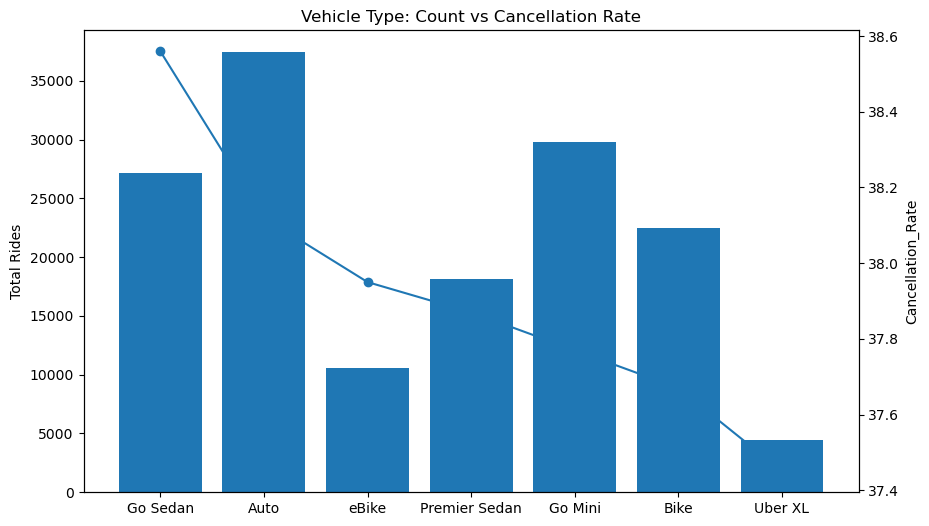

In [129]:
vehicle_table = vehicle_table.reset_index()

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar for counts
ax1.bar(vehicle_table['Vehicle Type'], vehicle_table['Total_Rides'])
ax1.set_ylabel("Total Rides")

# Line for rate
ax2 = ax1.twinx()
ax2.plot(vehicle_table['Vehicle Type'], vehicle_table['Cancellation_Rate'], marker='o')
ax2.set_ylabel("Cancellation_Rate")

plt.title("Vehicle Type: Count vs Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

In [131]:
df_model.groupby('Vehicle Type')['is_cancelled'].mean().mul(100).round(2)

Vehicle Type
Auto             38.12
Bike             37.67
Go Mini          37.77
Go Sedan         38.56
Premier Sedan    37.87
Uber XL          37.45
eBike            37.95
Name: is_cancelled, dtype: float64

In [67]:
df_model = df_model.drop(columns=['Time','Date','day_name'])

In [68]:
df_model = pd.get_dummies(df_model, drop_first=True)

In [69]:
df_model.isnull().sum().sum()

0

In [70]:
df_model.head()

,Avg VTAT,Avg CTAT,Booking Value,Ride Distance,is_cancelled,hour,day_of_week,Vehicle Type_Bike,Vehicle Type_Go Mini,Vehicle Type_Go Sedan,...,Drop Location_Welcome,Drop Location_Yamuna Bank,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_UPI,Payment Method_Uber Wallet,time_period_Early Morning,time_period_Evening,time_period_Morning,time_period_Night
0,8.3,28.8,414.0,23.72,1,12,5,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,4.9,14.0,237.0,5.73,1,18,4,False,False,True,...,False,False,False,False,True,False,False,True,False,False
2,13.4,25.8,627.0,13.58,0,8,4,False,False,False,...,False,False,False,True,False,False,True,False,False,False
3,13.1,28.5,416.0,34.02,0,17,0,False,False,False,...,False,False,False,False,True,False,False,True,False,False
4,5.3,19.6,737.0,48.21,0,22,0,True,False,False,...,False,False,False,False,True,False,False,False,False,True


## Model Building

In [72]:
X = df_model.drop(columns=['is_cancelled'])
y = df_model['is_cancelled']

In [73]:
list(X.columns)

['Avg VTAT',
 'Avg CTAT',
 'Booking Value',
 'Ride Distance',
 'hour',
 'day_of_week',
 'Vehicle Type_Bike',
 'Vehicle Type_Go Mini',
 'Vehicle Type_Go Sedan',
 'Vehicle Type_Premier Sedan',
 'Vehicle Type_Uber XL',
 'Vehicle Type_eBike',
 'Pickup Location_Adarsh Nagar',
 'Pickup Location_Akshardham',
 'Pickup Location_Ambience Mall',
 'Pickup Location_Anand Vihar',
 'Pickup Location_Anand Vihar ISBT',
 'Pickup Location_Ardee City',
 'Pickup Location_Arjangarh',
 'Pickup Location_Ashok Park Main',
 'Pickup Location_Ashok Vihar',
 'Pickup Location_Ashram',
 'Pickup Location_Aya Nagar',
 'Pickup Location_Azadpur',
 'Pickup Location_Badarpur',
 'Pickup Location_Badshahpur',
 'Pickup Location_Bahadurgarh',
 'Pickup Location_Barakhamba Road',
 'Pickup Location_Basai Dhankot',
 'Pickup Location_Bhikaji Cama Place',
 'Pickup Location_Bhiwadi',
 'Pickup Location_Botanical Garden',
 'Pickup Location_Central Secretariat',
 'Pickup Location_Chanakyapuri',
 'Pickup Location_Chandni Chowk',
 'Picku

### Train-Test Split

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

In [75]:
## XGBoosting - Handling Class Imbalance
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Calculate scale_pos_weight to handle class imbalance
n_negatives = (y_train == 0).sum()
n_positives = (y_train == 1).sum()
scale_pos_weight = n_negatives / n_positives
print(f"Class distribution in training set:")
print(f"  Not Cancelled (0): {n_negatives}")
print(f"  Cancelled (1): {n_positives}")
print(f"  Imbalance Ratio: {scale_pos_weight:.2f}:1")
print(f"  Using scale_pos_weight: {scale_pos_weight:.2f}")

# Initialize model with scale_pos_weight to handle imbalance
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Handles class imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Scores
xgb_train_score = xgb.score(X_train, y_train)
xgb_test_score = xgb.score(X_test, y_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

# Display results
print(f"\nTraining Accuracy: {xgb_train_score:.4f}")
print(f"Testing Accuracy: {xgb_test_score:.4f}")
print(f"Overall Accuracy: {xgb_acc:.4f}")
print(f"Train-Test Gap: {xgb_train_score - xgb_test_score:.4f}")


## Model Transformation

In [ ]:
# Check distributions and skewness
# Then transform

## Feature Scaling

## Treating the Imbalance

In [ ]:
# Apply on SCALED data

## Model Selection

In [77]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score

In [78]:
models = []
models.append(('Logistic Regression' ,LogisticRegression(random_state=42)))
models.append(('Naive bayes', GaussianNB()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('Random Forest', RandomForestClassifier(random_state = 42)))
models.append(('SGD Classifier', SGDClassifier(random_state=42)))
models.append(('XGBoost', XGBClassifier(random_state = 42)))
models.append(('GradientBoosting', GradientBoostingClassifier(random_state = 42)))
results = []
names = []

In [79]:
for name, model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        print("{} : {}".format(name,accuracy))

C:\Users\tsrap\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression : 0.8102333333333334
Naive bayes : 0.7041
KNN : 0.9439
Random Forest : 0.9579
SGD Classifier : 0.6746333333333333
XGBoost : 0.9558
GradientBoosting : 0.9579333333333333


## Logistic Regression

In [145]:
#creating a copy of the dataframe to work my model on so i am not editing the main code 
dfLRModel = df.copy()
#check
#dfLRModel.head(5)
#model preparation
#define x and y 
#x is being chosen based off of "what information would i have before the ride happens"
#because we are building a model that answers "at booking time, can i predict if this ride will fail?"
features = ['Vehicle Type', 'Pickup Location', 'Drop Location', 'Booking Value',
            'Ride Distance', 'Avg VTAT', 'Avg CTAT', 'Payment Method',
            'hour', 'day_name', 'time_period']

In [147]:
y = dfLRModel['is_cancelled'] #this represents did the ride fail (1) or succeed (0)
X = dfLRModel[features]

In [149]:
#split data into train/test sets
import sklearn.model_selection as ms
XTrain, XTest, yTrain, yTest = ms.train_test_split(X, y, test_size=0.3, random_state=1)

In [157]:
#encode categorical variables
XTrain = pd.get_dummies(XTrain, drop_first=True)
XTest = pd.get_dummies(XTest, drop_first=True)

In [159]:
#align train and test columns
XTrain, XTest = XTrain.align(XTest, join='left', axis=1, fill_value=0)

In [161]:
#save feature names for interpreting the model after which is a list of all the features after encoding
featureNames = XTrain.columns

In [163]:
#impute missing values - Since logistic regression cannot handle missing values directly, median imputation was applied to the remaining numerical 
#features after encoding and before scaling, this preserved all observations while ensuring the gradient-based optimization algorithm could train successfully
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
XTrain = imputer.fit_transform(XTrain)
XTest = imputer.transform(XTest)

In [165]:
#scale features - feature scaling ensures that gradient descent converges efficiently 
#by preventing features with large magnitudes from dominating the optimization process
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
XTrain = scaler.fit_transform(XTrain)
XTest = scaler.transform(XTest)


In [167]:
#model training
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(XTrain, yTrain)


LogisticRegression(max_iter=1000)

In [173]:
#evaluation
from sklearn.metrics import confusion_matrix, classification_report
yPred = model.predict(XTest)
#confusions and classification report 
print(confusion_matrix(yTest, yPred))
print(classification_report(yTest, yPred))
#printing what the model learned here by creating a table that shows each feature + how important it is in predicting cancellations
coefdf = pd.DataFrame({
    'Feature': featureNames,
    'Coefficient': model.coef_[0]
})

[[23339  4565]
 [ 1796 15300]]
              precision    recall  f1-score   support

           0       0.93      0.84      0.88     27904
           1       0.77      0.89      0.83     17096

    accuracy                           0.86     45000
   macro avg       0.85      0.87      0.85     45000
weighted avg       0.87      0.86      0.86     45000



In [177]:
#printing the most negative and positive coefficients
print(coefdf.sort_values(by='Coefficient', ascending=False).head(10))
print(coefdf.sort_values(by='Coefficient', ascending=True).head(10))

                         Feature  Coefficient
367              day_name_Sunday     0.031081
366            day_name_Saturday     0.022910
314       Drop Location_RK Puram     0.022167
209     Drop Location_Chhatarpur     0.020220
182   Pickup Location_Vinobapuri     0.017231
191     Drop Location_Ardee City     0.016909
339        Drop Location_Sonipat     0.015791
322    Drop Location_Rohini East     0.014950
342  Drop Location_Subhash Nagar     0.014909
221      Drop Location_GTB Nagar     0.014349
                           Feature  Coefficient
363             Payment Method_UPI    -1.793951
364     Payment Method_Uber Wallet    -1.064304
361     Payment Method_Credit Card    -0.980992
362      Payment Method_Debit Card    -0.904632
1                    Ride Distance    -0.824407
3                         Avg CTAT    -0.775641
0                    Booking Value    -0.337274
2                         Avg VTAT    -0.142658
58     Pickup Location_Gwal Pahari    -0.033007
167  Pickup Lo

## XGBoosting

In [183]:
## XGBoosting - Updated with Imbalance Handling
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Calculate scale_pos_weight to handle class imbalance
n_negatives = (y_train == 0).sum()
n_positives = (y_train == 1).sum()
scale_pos_weight = n_negatives / n_positives
print(f"Class distribution:")
print(f"  Not Cancelled (0): {n_negatives}")
print(f"  Cancelled (1): {n_positives}")
print(f"  Imbalance Ratio: {scale_pos_weight:.2f}:1")

# Initialize model with scale_pos_weight
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Handles class imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Train model
xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)

# Scores
xgb_train_score = xgb.score(X_train, y_train)
xgb_test_score = xgb.score(X_test, y_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

# Display results
print(f"\nTraining Accuracy: {xgb_train_score:.4f}")
print(f"Testing Accuracy: {xgb_test_score:.4f}")
print(f"Overall Accuracy: {xgb_acc:.4f}")
print(f"Train-Test Gap: {xgb_train_score - xgb_test_score:.4f}")


(0.9574583333333333, 0.958, 0.958)

In [185]:
xgb_train_score - xgb_test_score


-0.0005416666666666625

## XGBoost with CV

In [188]:
## XGBoost with CV - Updated with Imbalance Handling
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

# Calculate scale_pos_weight for imbalance handling
n_negatives = (y_train == 0).sum()
n_positives = (y_train == 1).sum()
scale_pos_weight = n_negatives / n_positives
print(f"Using scale_pos_weight: {scale_pos_weight:.2f}")

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Handles class imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

# Cross-validation ONLY on training data
xgb_cv_scores = cross_val_score(
    estimator=xgb,
    X=X_train,
    y=y_train,
    cv=10,
    scoring='accuracy'
)

xgb_cv_scores.mean(), xgb_cv_scores

print(f"Cross-Validation Mean Accuracy: {xgb_cv_scores.mean():.4f}")


(0.9567,
 array([0.95491667, 0.95675   , 0.95675   , 0.95725   , 0.9575    ,
        0.95683333, 0.95658333, 0.95791667, 0.95425   , 0.95825   ]))

In [190]:
from sklearn.metrics import accuracy_score

# Fit model on training data
xgb.fit(X_train, y_train)

# Predictions
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)

# Accuracy scores
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_acc, test_acc


(0.9574583333333333, 0.958)

In [192]:
cv_acc = xgb_cv_scores.mean()

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Cross-Validation Accuracy: {cv_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Accuracy: 0.9575
Cross-Validation Accuracy: 0.9567
Test Accuracy: 0.9580


In [194]:
overfit_gap = train_acc - test_acc
overfit_gap

-0.0005416666666666625

In [198]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     18642
           1       1.00      0.89      0.94     11358

    accuracy                           0.96     30000
   macro avg       0.97      0.94      0.95     30000
weighted avg       0.96      0.96      0.96     30000



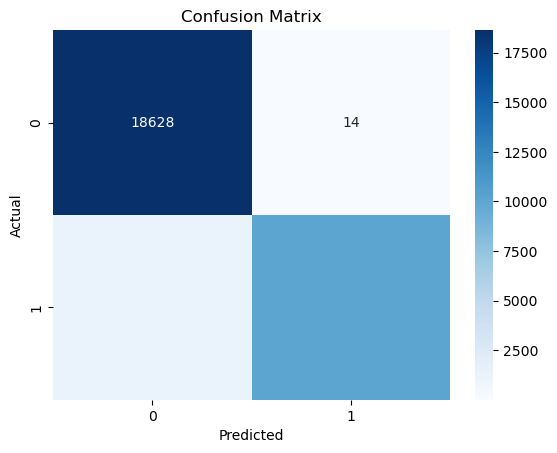

In [200]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Complete XGBoost implementation with class imbalance handling


from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Handle Class Imbalance
print("="*80)
print("XGBOOST MODEL - COMPLETE IMPLEMENTATION WITH IMBALANCE HANDLING")
print("="*80)

# Calculate scale_pos_weight to handle class imbalance
n_negatives = (y_train == 0).sum()
n_positives = (y_train == 1).sum()
scale_pos_weight = n_negatives / n_positives

print("\nClass Distribution:")
print(f"  Not Cancelled (0): {n_negatives} ({n_negatives/len(y_train)*100:.2f}%)")
print(f"  Cancelled (1): {n_positives} ({n_positives/len(y_train)*100:.2f}%)")
print(f"  Imbalance Ratio: {scale_pos_weight:.2f}:1")
print(f"  scale_pos_weight: {scale_pos_weight:.2f}")


#  Train XGBoost with Imbalance Handling
print("\n" + "="*80)
print("TRAINING XGBOOST MODEL")
print("="*80)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # Handles class imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb.fit(X_train, y_train)
print("✓ Model training complete")

# Training and Testing Accuracy
print("\n" + "="*80)
print("MODEL ACCURACY")
print("="*80)

xgb_train_score = xgb.score(X_train, y_train)
xgb_test_score = xgb.score(X_test, y_test)
xgb_acc = accuracy_score(y_test, xgb.predict(X_test))

print(f"Training Accuracy: {xgb_train_score:.4f} ({xgb_train_score*100:.2f}%)")
print(f"Testing Accuracy: {xgb_test_score:.4f} ({xgb_test_score*100:.2f}%)")
print(f"Overall Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.2f}%)")
print(f"Train-Test Gap: {xgb_train_score - xgb_test_score:.4f}")

# = Confusion Matrix

print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

y_pred = xgb.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print(f"\nActual vs Predicted:")
print(f"                     Predicted Not Cancelled    Predicted Cancelled")
print(f"Actual Not Cancelled:    {TN:<10}              {FP:<10}")
print(f"Actual Cancelled:        {FN:<10}              {TP:<10}")

print(f"\nBreakdown:")
print(f"  True Positives (TP):  {TP} - Correctly predicted cancellations")
print(f"  True Negatives (TN):  {TN} - Correctly predicted non-cancellations")
print(f"  False Positives (FP): {FP} - Incorrectly predicted as cancellations")
print(f"  False Negatives (FN): {FN} - Missed cancellations")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Cancelled', 'Cancelled'],
            yticklabels=['Not Cancelled', 'Cancelled'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - XGBoost with Imbalance Handling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


#  Classification Report

print("\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(y_test, y_pred, target_names=['Not Cancelled (0)', 'Cancelled (1)']))

# Feature Importance
print("="*80)
print("TOP 10 FEATURE IMPORTANCE")
print("="*80)

importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(f"\n{'Rank':<6} {'Feature':<45} {'Importance':<12}")
print("-"*65)
for i, (idx, row) in enumerate(importance.head(10).iterrows(), 1):
    print(f"{i:<6} {row['Feature']:<45} {row['Importance']:<12.4f}")

# Visualize feature importance
plt.figure(figsize=(10, 8))
top_15 = importance.head(15)
plt.barh(range(len(top_15)), top_15['Importance'], color='teal')
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.gca().invert_yaxis()
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importance - XGBoost with Imbalance Handling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"✓ Model: XGBoost with scale_pos_weight = {scale_pos_weight:.2f}")
print(f"✓ Training Accuracy: {xgb_train_score*100:.2f}%")
print(f"✓ Testing Accuracy: {xgb_test_score*100:.2f}%")
print(f"✓ Cancelled Class Performance:")
print(f"    - Precision: {TP/(TP+FP):.4f}")
print(f"    - Recall: {TP/(TP+FN):.4f}")
print(f"    - F1-Score: {2*TP/(2*TP+FP+FN):.4f}")
print(f"✓ Most Important Feature: {importance.iloc[0]['Feature']} ({importance.iloc[0]['Importance']:.4f})")
print("="*80)
print("\n✅ XGBoost model successfully trained with class imbalance handling!")
print("="*80)


Logistic Regression

Random Forest 

Naive Bayes 

The heatmap shows that most variables in the dataset have very weak or no linear relationships with each other, as indicated by values close to 0 (dark blue). A few pairs, like ride distance and average CTAT, show slight positive correlation, but it is still weak and not strong enough to rely on. 

Several blank areas appear because columns with very high missing values (like cancellation and incomplete ride features) do not have enough data to compute correlations. 

Overall, this indicates that correlation is not useful for imputing missing values in this dataset, and a logic-based or group-based approach is more appropriate.

The target variable was created by grouping multiple booking statuses into a binary outcome, where all unsuccessful ride outcomes (including cancellations, incomplete rides, and no-driver-found cases) were treated as cancellations.

df['Reason for cancelling by Customer'].unique()

After performing exploratory data analysis (EDA) on the full dataset to understand patterns and key reasons behind ride cancellations, columns that directly reflect the outcome of a ride (such as cancellation counts, cancellation reasons, and incomplete ride details) will be removed before modeling. 

These features were excluded because they are only available after the event has occurred and would introduce data leakage, leading to artificially high model performance. In simple words, our goal is to predict cancellation before it happens but columns like 
'Reason for cancelling by Customer','Driver Cancellation Reason','Cancelled Rides by Customer','Cancelled Rides by Driver','Incomplete Rides',and 'Incomplete Rides Reason' explains cancellation after it happens. This introduces to data leakage!

Additionally, identifier columns like Booking ID and Customer ID were dropped as they do not contribute meaningful predictive information. This ensures that the model is trained only on features available prior to the ride, making it realistic and reliable for prediction.

Cancellation behavior varies by location, with some areas showing higher risk (rate) and others showing higher volume (count). This indicates both demand and location-specific factors influence ride cancellations.

The reasons for cancellation could be the following:
Driver availability
Traffic conditions
Matching inefficiencies